## 1. Import libraries 

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O
import os
from PIL import Image
from sklearn.neighbors import NearestNeighbors
from PIL import Image, ImageOps
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from __future__ import print_function
#%matplotlib inline
import argparse
import os
import time
import shutil
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# set random seed for reproducibility
manualSeed = 999
# manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

# image directory
image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
# get 10 images
image_files = os.listdir(image_dir)[:10]

# traverse through image files
for i, file_name in enumerate(image_files, 1):
    # iterate over the image files that get and
    # join the path to open each image
    image_path = os.path.join(image_dir, file_name)
    with Image.open(image_path) as img:
        print(f"Image {i}: {file_name} - Size: {img.size}") 

Random Seed:  999
Image 1: ISIC_9730802.jpg - Size: (139, 139)
Image 2: ISIC_2834883.jpg - Size: (125, 125)
Image 3: ISIC_5115027.jpg - Size: (123, 123)
Image 4: ISIC_3264822.jpg - Size: (115, 115)
Image 5: ISIC_1950204.jpg - Size: (147, 147)
Image 6: ISIC_8411738.jpg - Size: (145, 145)
Image 7: ISIC_3744117.jpg - Size: (133, 133)
Image 8: ISIC_0989720.jpg - Size: (131, 131)
Image 9: ISIC_3926794.jpg - Size: (139, 139)
Image 10: ISIC_2892810.jpg - Size: (107, 107)


In [2]:
# metadata directory 
meta_dir = "/kaggle/input/isic-2024-challenge/"

# read the csv file
df = pd.read_csv(meta_dir + "train-metadata.csv")

# display head
df.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


## 2. Make dataset CSV from Full dataset
Create 1:20 ratio for align with the state of the art

1 - > positive 393

0 - > negative 7860

In [3]:
# filter malignant (target == 1)
df_positive = df[df["target"] == 1]

# filter benign (target == 0), randomly sample 7860 rows
df_negative = df[df["target"] == 0].sample(n=7860, random_state=42)

# combine both positive and negative cases
df_balanced = pd.concat([df_positive, df_negative]).reset_index(drop=True)

# shuffle the data
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# save to a new CSV
df_balanced.to_csv("/kaggle/working/created_from_fulldataset.csv", index=False)

## 2. Make (training valdation and testing) dataset CSV from Full dataset

1. Train distribution:

> 55021     275


2. Validation distribution:

> 11791      59


3. Test distribution:


> 11791      59


In [4]:
from sklearn.model_selection import train_test_split

# shuffle dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# first split: Train (70%) and Temp (30%) with stratification
train_df, temp_df = train_test_split(
    df_balanced,
    test_size=0.30,
    stratify=df_balanced["target"],   # ensures same pos/neg ratio
    random_state=42
)

# second split: Validation (15%) and Test (15%) with stratification
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["target"],       # ensures balance in val/test
    random_state=42
)

# Check class balance
print("Train distribution:\n", train_df["target"].value_counts())
print("\nValidation distribution:\n", val_df["target"].value_counts())
print("\nTest distribution:\n", test_df["target"].value_counts())

Train distribution:
 target
0    5502
1     275
Name: count, dtype: int64

Validation distribution:
 target
0    1179
1      59
Name: count, dtype: int64

Test distribution:
 target
0    1179
1      59
Name: count, dtype: int64


In [5]:
# save
train_df.to_csv("/kaggle/working/train.csv", index=False)
val_df.to_csv("/kaggle/working/val.csv", index=False)
test_df.to_csv("/kaggle/working/test.csv", index=False)

## 3. Make the dataloader and get the dataset

Apply some transformation to lager the dataset.

Make the dataset.

In [6]:
# custom dataset class 
# this implement how one training data is get from the dataset
# if transformation is needed need to pass the transformation to transform
class ISICDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_dir, f"{row['isic_id']}.jpg")
        image = Image.open(image_path).convert("RGB")
        
        # resize and center crop using ImageOps.fit
        image = ImageOps.fit(image, (128, 128), method=Image.BICUBIC)

        if self.transform:
            image = self.transform(image)

        label = int(row['target'])
        return image, label

### Use only train and validation for further 
## 4. Make encoder and decoder 

In [7]:
# create encoder module this is used to encode the image
class Encoder(nn.Module):
    def __init__(self, n_channel, dim_h, n_z):
        super(Encoder, self).__init__()

        # number of input channels
        self.n_channel = n_channel
        # input image size 
        self.dim_h = dim_h
        # latent space size
        self.n_z = n_z
        
        # convolutional filters
        # we use 5 convolution layers as our image is 64x64
        self.conv = nn.Sequential(
            
            # 1 st convolution layer 
            nn.Conv2d(self.n_channel, self.dim_h, 4, 2, 1, bias=False),
            #nn.ReLU(True),(32 x 32 x 64)
            nn.LeakyReLU(0.2, inplace=True),
            
            # 2 nd convolution layer
            nn.Conv2d(self.dim_h, self.dim_h * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(self.dim_h * 2),
            #nn.ReLU(True),(16 x 16 x 64*2)
            nn.LeakyReLU(0.2, inplace=True),

            # 3 rd convolution layer 
            nn.Conv2d(self.dim_h * 2, self.dim_h * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(self.dim_h * 4),
            #nn.ReLU(True),(8 x 8 x 64*4)
            nn.LeakyReLU(0.2, inplace=True),
            
            
            # 4 th convolution layer
            nn.Conv2d(self.dim_h * 4, self.dim_h * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(self.dim_h * 8),
            #nn.ReLU(True),(4 x 4 x 64*8)
            nn.LeakyReLU(0.2, inplace=True),

            # 5 th convolution layer
            nn.Conv2d(self.dim_h * 8, self.dim_h * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(self.dim_h * 16),
            #nn.ReLU(True),(1 x 1 x 64*16)
            nn.LeakyReLU(0.2, inplace=True)) 

        
        # final layer is fully connected
        self.fc = nn.Linear(self.dim_h * (2 ** 4), self.n_z)
        

    def forward(self, x):
        # print('enc')
        # input size is torch.Size([128, 3, 64, 64])
        
        x = self.conv(x)
        # print(x.size()) # torch.Size([128, 1024, 1, 1])
        
        x = x.squeeze()
        # print('aft squeeze ',x.size()) # torch.Size([128, 1024])
        
        
        x = self.fc(x)
        # print('out ',x.size()) #torch.Size([128, 320])
        
        # out  torch.Size([128, 300])
        return x

In [8]:
class Decoder(nn.Module):
    def __init__(self, n_channel, dim_h, n_z):
        super(Decoder, self).__init__()
        
        # number of input channels
        self.n_channel = n_channel
        # input image size 
        self.dim_h = dim_h
        # latent space size
        self.n_z = n_z

        # first layer is fully connected
        self.fc = nn.Sequential(
            nn.Linear(self.n_z, self.dim_h * 8 * 8 * 8),
            nn.ReLU())

        # 4 deconvolutional filters as encoder has 5 convolution layers
        self.deconv = nn.Sequential(
            # 1 st deconvolution layer 
            nn.ConvTranspose2d(self.dim_h * 8, self.dim_h * 4, 4, stride=2, padding=1),
            nn.BatchNorm2d(self.dim_h * 4),
            nn.ReLU(True),

            # 2 nd deconvolution layer 
            nn.ConvTranspose2d(self.dim_h * 4, self.dim_h * 2, 4, stride=2, padding=1),
            nn.BatchNorm2d(self.dim_h * 2),
            nn.ReLU(True),

            # 3 rd deconvolution layer 
            nn.ConvTranspose2d(self.dim_h * 2, self.dim_h, 4, stride=2, padding=1),
            nn.BatchNorm2d(self.dim_h),
            nn.ReLU(True),

            # 4 th deconvolution layer 
            nn.ConvTranspose2d(self.dim_h, 3, 3, stride=1, padding=1),
            #nn.Sigmoid())
            nn.Tanh())

    def forward(self, x):
        #print('dec')
        # print('input ',x.size())
        x = self.fc(x)
        
        # after the latent space make as channels to pass to the deconvolution layers
        x = x.view(-1, self.dim_h * 8, 8, 8)
        
        # deconvolve the layer
        x = self.deconv(x)

        # output the image
        return x

In [9]:
# batch size during training
batch_size = 128

# size using a transformer.
image_size = 64

# number of channels in the training images. For color images this is 3
nc = 3

# size of latent space
n_z = 300

In [10]:
# initialize encoder and decoder
encoder = Encoder(nc, image_size, n_z)
decoder = Decoder(nc, image_size, n_z)

# find available gpus
t0 = time.time()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

# add to the encoder and decoder to the device
decoder = decoder.to(device)
encoder = encoder.to(device)

cpu


## 5. Load the encoder and decoder from hugging face

In [11]:
# load the weights back
from huggingface_hub import hf_hub_download
import torch

# download encoder weights
encoder_path = hf_hub_download(
    repo_id="Hansiduyapa/autoencoder-model",  # change to your actual repo ID
    filename="encoder.pth"
)

# download decoder weights
decoder_path = hf_hub_download(
    repo_id="Hansiduyapa/autoencoder-model",
    filename="decoder.pth"
)

# load weights into model
encoder.load_state_dict(torch.load(encoder_path, map_location=torch.device(device))) #map_location=torch.device('cpu')))
decoder.load_state_dict(torch.load(decoder_path, map_location=torch.device(device))) #map_location=torch.device('cpu')))

encoder.pth:   0%|          | 0.00/45.8M [00:00<?, ?B/s]

decoder.pth:   0%|          | 0.00/50.5M [00:00<?, ?B/s]

<All keys matched successfully>

## 6. Generate synthetic data from Encoder and Decoder

More positive data is generated from the training set 

> 50% - 100% - 150% - 200% - ..

**Interpolation the vector space**

In [12]:
# X data size is the (number_of_dataset, n_vector_space)
# n_to_sample number of samples to generate
# cl means number of class the index of the class
def G_SM1(X, y,n_to_sample,cl):
    
    # if the incoming x data is more than 5 samples
    if (X.shape[0] > 5):
        n_neigh = 5 + 1
    else:
        # if not get the neighbors as available points
        n_neigh = X.shape[0]
        
    # initialize the model with the NearestNeighbors
    nn = NearestNeighbors(n_neighbors=n_neigh, n_jobs=1)
    nn.fit(X)
    
    # Returns indices of neighbors of each point
    # ind means the nearest neighbours to each point in
    dist, ind = nn.kneighbors(X)
    ##########
    # ind is the indexes of nearest neighbors that are close to the current index
    ##########
    
    # generating samples
    # get random index list from the data
    # base_indices that are get for generating new samples
    base_indices = np.random.choice(list(range(len(X))),n_to_sample)

    # considered neighbors that are most nearest neighbours
    neighbor_indices = np.random.choice(list(range(1, n_neigh)),n_to_sample)

    # get the correct data from the x    
    X_base = X[base_indices]
    X_neighbor = X[ind[base_indices, neighbor_indices]]

    # calculate samples based on the random value 
    # interpolate the vectors
    samples = X_base + np.multiply(np.random.rand(n_to_sample,1),
            X_neighbor - X_base)

    # return the vectors size: (n_to_sample x n_vector_space)
    # and there corresponding labels size: (n_to_sample)
    # return class and the label
    return samples, [cl]*n_to_sample

In [13]:
image_size = 64
transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.ToTensor(),
                           ])

### Exp1: Generate more than 50% in positive cases

Class Basal cell carcinoma: 115 real samples → generating 57 new samples
Saved 57 images for class Basal cell carcinoma


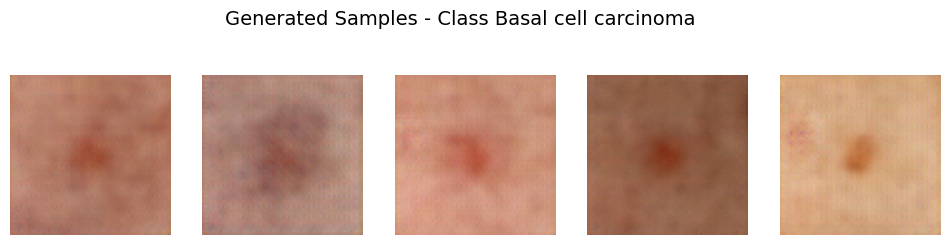

Class Melanoma Invasive: 47 real samples → generating 23 new samples
Saved 23 images for class Melanoma Invasive


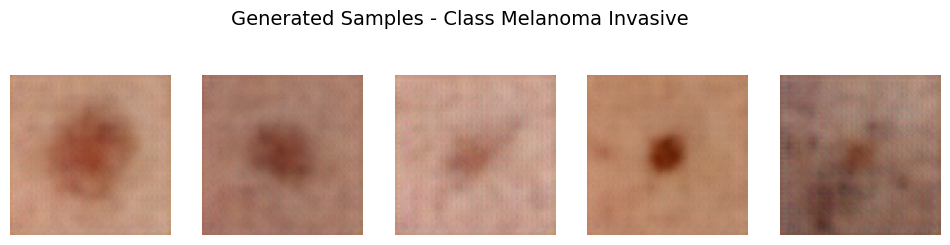

Class Melanoma, NOS: 13 real samples → generating 6 new samples
Saved 6 images for class Melanoma, NOS


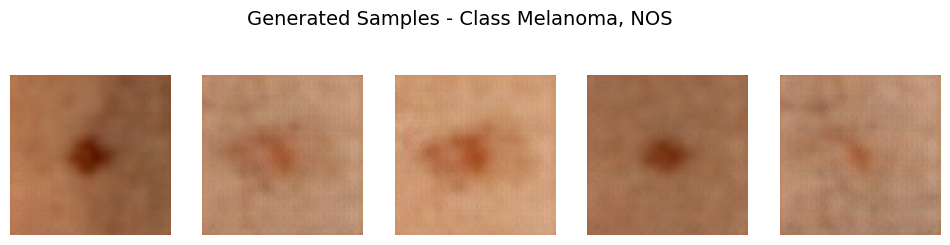

Class Melanoma in situ: 55 real samples → generating 27 new samples
Saved 27 images for class Melanoma in situ


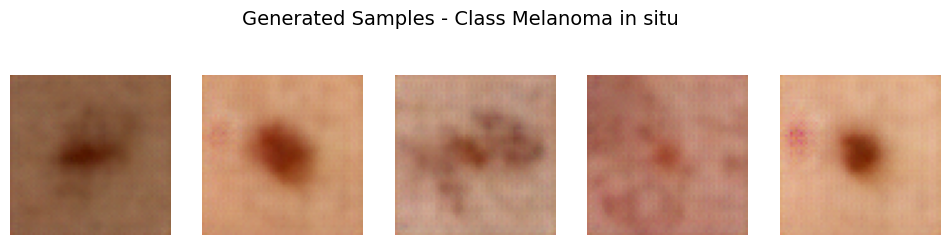

Class Squamous cell carcinoma in situ: 32 real samples → generating 16 new samples
Saved 16 images for class Squamous cell carcinoma in situ


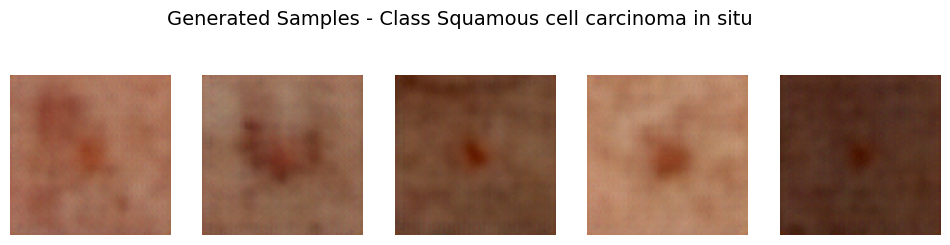

Class Squamous cell carcinoma, Invasive: 10 real samples → generating 5 new samples
Saved 5 images for class Squamous cell carcinoma, Invasive


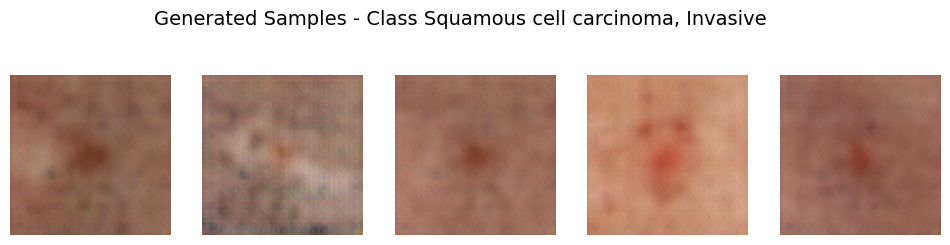

Not enough samples for class Melanoma metastasis to generate new data. Skipping.
Class Squamous cell carcinoma, NOS: 2 real samples → generating 1 new samples
Saved 1 images for class Squamous cell carcinoma, NOS


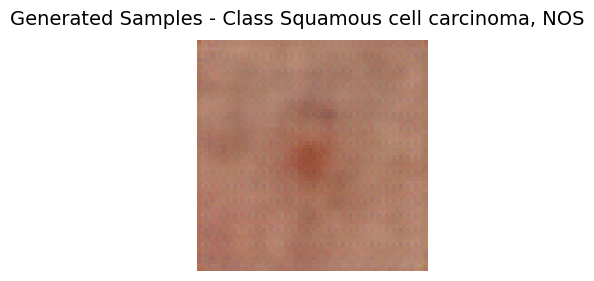

In [14]:
# encoder and decoder convert it to eval
encoder.eval()
decoder.eval()

# get the training dataset only 
train_df = pd.read_csv("/kaggle/working/train.csv")

save_dir = '/kaggle/working/generated_50_percentage'
os.makedirs(save_dir, exist_ok=True)

# get only positive cases for generating new data poin
df_filtered = train_df[train_df["target"] == 1]

# get distinct classes from the filtered dataFrame
unique_classes = df_filtered['iddx_3'].unique()

# percentage of generated images relative to real samples
# 0.5 → 50%, 1.0 → 100%, 2.0 → 200%, etc.
gen_percent = 0.5 

for cl in unique_classes:
    df_class = df_filtered[df_filtered['iddx_3'] == cl]

    dataset_class = ISICDataset(df_class, image_dir, transform=transform)

    # extract latent vectors
    X_class = []
    for img, _ in dataset_class:
        img = img.unsqueeze(0).to(device)
        with torch.no_grad():
            z = encoder(img)
        X_class.append(z.cpu().numpy().squeeze())

    X_class = np.array(X_class)

    if len(X_class) < 2:
        print(f"Not enough samples for class {cl} to generate new data. Skipping.")
        continue

    y_class = [cl] * len(X_class)

    # number of new samples based on percentage
    n_real = len(X_class)
    n_to_sample = int(n_real * gen_percent)

    print(f"Class {cl}: {n_real} real samples → generating {n_to_sample} new samples")

    # generated samples
    new_vectors, _ = G_SM1(X_class, y_class, n_to_sample, cl)

    z = torch.tensor(new_vectors, dtype=torch.float32).to(device)
    with torch.no_grad():
        generated_images = decoder(z).cpu()

    # save generated images
    for i in range(n_to_sample):
        img = generated_images[i].squeeze()
        img = img.permute(1, 2, 0)
        img = img.clamp(0, 1).numpy() * 255
        img = Image.fromarray(img.astype(np.uint8))

        img_filename = f"{cl}_generated_{i}.jpg"
        img.save(os.path.join(save_dir, img_filename))

    print(f"Saved {n_to_sample} images for class {cl}")

    n_show = min(5, n_to_sample)
    fig, axs = plt.subplots(1, n_show, figsize=(12, 3))
    fig.suptitle(f"Generated Samples - Class {cl}", fontsize=14)

    # make axs always iterable
    if n_show == 1:
        axs = [axs]
    
    for i in range(n_show):
        img = generated_images[i].squeeze()
        img = img.permute(1, 2, 0)
        img = img.clamp(0, 1).numpy()
        axs[i].imshow(img)
        axs[i].axis('off')

    plt.show()

## 7. Make full Dataset with the generated images

In [15]:
full_dir = '/kaggle/working/generated_50_and_all'

In [16]:
# get the ids of the generated images and make a dataframe
save_dir = '/kaggle/working/generated_50_percentage'

# get filenames of generated images
generated_files = [f for f in os.listdir(save_dir) if f.endswith('.jpg')]

# Extract isic_ids from filenames (remove extension)
generated_ids = [f.replace('.jpg', '') for f in generated_files]

# create DataFrame for generated images (label = 1)
generated_df = pd.DataFrame({
    'isic_id': generated_ids,
    'target': 1
})

In [17]:
print(len(generated_df))
generated_df.head()

135


,isic_id,target
0,Squamous cell carcinoma in situ_generated_11,1
1,Melanoma in situ_generated_5,1
2,Melanoma Invasive_generated_5,1
3,Basal cell carcinoma_generated_23,1
4,Basal cell carcinoma_generated_33,1


## 8. Make a copy of the train dataset to "generated_50_and_all"

Get the images from full dataset and copy to the "generated_50_and_all"

In [18]:
# Define directories
image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
full_dir = '/kaggle/working/generated_50_and_all'
os.makedirs(full_dir, exist_ok=True)

df_filtered = pd.read_csv("/kaggle/working/train.csv")

# Copy each image from image_dir to full_dir
for idx, row in df_filtered.iterrows():
    isic_id = row["isic_id"]
    src_path = os.path.join(image_dir, f"{isic_id}.jpg")
    dst_path = os.path.join(full_dir, f"{isic_id}.jpg")
    
    # Check if source image exists before copying
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
    else:
        print(f"Warning: {src_path} does not exist.")

In [19]:
# Combine original and generated datasets
final_train_df = pd.concat([df_filtered, generated_df], ignore_index=True)

## 9. Train a model on 50% generated images

In [30]:
from torch.utils.data import DataLoader

resize_dim = 64
transform = transforms.Compose([
    transforms.Resize((resize_dim, resize_dim)),  # Resize to (H, W)
    transforms.ToTensor(),                        # Convert to tensor and scale [0, 255] → [0, 1]
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # Normalize for 3-channel RGB
])

In [31]:
train_dataset = ISICDataset(train_df, full_dir, transform)
val_dataset = ISICDataset(val_df, image_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

## 10. Make a simple CNN model

In [32]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 64→32
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 32→16
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2) # 16→8
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x  # raw logits

In [33]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model, loss, optimizer
model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [34]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import torch

# Metric storage
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(10):
    model.train()
    running_loss = 0.0
    train_preds, train_labels = [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        preds = torch.sigmoid(logits).detach().cpu().numpy() > 0.5
        train_preds.extend(preds.flatten())
        train_labels.extend(labels.cpu().numpy())

    avg_train_loss = running_loss / len(train_loader.dataset)
    train_acc = accuracy_score(train_labels, train_preds)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
            logits = model(imgs)
            loss = criterion(logits, labels)
            val_loss += loss.item() * imgs.size(0)

            preds = torch.sigmoid(logits).cpu().numpy() > 0.5
            val_preds.extend(preds.flatten())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(val_labels, val_preds)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: "
          f"Train Loss = {avg_train_loss:.4f}, Train Acc = {train_acc:.4f}, "
          f"Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")

Epoch 1: Train Loss = 0.2062, Train Acc = 0.9434, Val Loss = 0.1749, Val Acc = 0.9523
Epoch 2: Train Loss = 0.1855, Train Acc = 0.9524, Val Loss = 0.1472, Val Acc = 0.9523
Epoch 3: Train Loss = 0.1567, Train Acc = 0.9533, Val Loss = 0.1357, Val Acc = 0.9604
Epoch 4: Train Loss = 0.1496, Train Acc = 0.9557, Val Loss = 0.1318, Val Acc = 0.9588
Epoch 5: Train Loss = 0.1479, Train Acc = 0.9531, Val Loss = 0.1309, Val Acc = 0.9596
Epoch 6: Train Loss = 0.1434, Train Acc = 0.9546, Val Loss = 0.1438, Val Acc = 0.9596
Epoch 7: Train Loss = 0.1385, Train Acc = 0.9545, Val Loss = 0.1295, Val Acc = 0.9620
Epoch 8: Train Loss = 0.1353, Train Acc = 0.9566, Val Loss = 0.1269, Val Acc = 0.9588
Epoch 9: Train Loss = 0.1354, Train Acc = 0.9569, Val Loss = 0.1260, Val Acc = 0.9620
Epoch 10: Train Loss = 0.1364, Train Acc = 0.9569, Val Loss = 0.1485, Val Acc = 0.9596


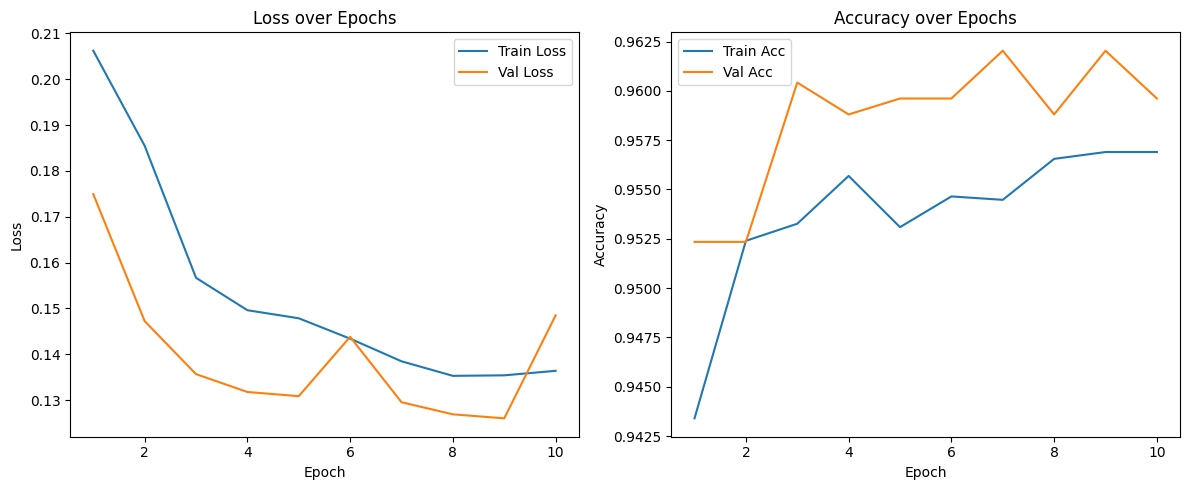

In [35]:
# Plotting
epochs = range(1, 11)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Acc')
plt.plot(epochs, val_accuracies, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

## 11. Inference on testing Dataset

get the testing dataset and 

In [36]:
test_dataset = ISICDataset(test_df, image_dir, transform)
test_loader = DataLoader(test_dataset, batch_size=64)

Accuracy: 0.9564
F1 Score: 0.3250
Confusion Matrix:
 [[1171    8]
 [  46   13]]


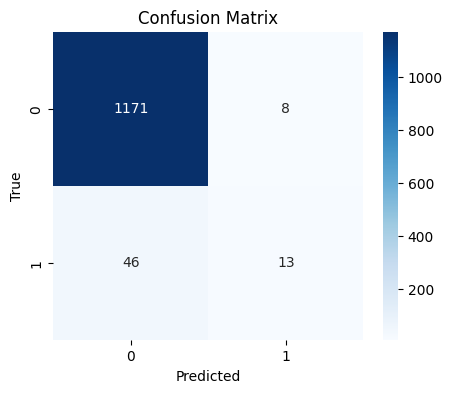

In [38]:
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# put model in evaluation mode
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # forward pass
        outputs = model(images).squeeze()   # shape: [batch_size]
        probs = torch.sigmoid(outputs)      # convert logits → probability [0,1]

        # threshold at 0.5 for binary prediction
        preds = (probs >= 0.5).long()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# compute metrics
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

# plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()